# Lyapunov Exponents and Correlations

This notebook contains the computation of the largest Lyapunov exponent and the correlation analysis between Lyapunov-based indicators and topological summaries.

### Block 1: Computation of the maximum Lyapunov exponent

In [4]:
import numpy as np
import pandas as pd

# ============================================================
# 0. UTILIDADES NUMERICAS
# ============================================================

def rk4_step_augmented(F, t, Y, h, params):
    """
    Un paso RK4 para el sistema aumentado:
    estado + vector variacional
    """
    k1 = F(t, Y, params)
    k2 = F(t + h/2, Y + h*k1/2, params)
    k3 = F(t + h/2, Y + h*k2/2, params)
    k4 = F(t + h, Y + h*k3, params)
    return Y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)


def largest_lyapunov_exponent(
    f, jac, x0, params,
    dt=0.01,
    Ttrans=20.0,
    Tstep=1.0,
    Nsteps=1200,
    v0=None
):
    """
    Calcula el mayor exponente de Lyapunov para un sistema continuo
    integrando conjuntamente:
        x' = f(x)
        v' = J(x)v
    y renormalizando cada Tstep.
    """

    x0 = np.asarray(x0, dtype=float)
    n = len(x0)

    if v0 is None:
        rng = np.random.default_rng(42)
        v0 = rng.normal(size=n)
    v0 = np.asarray(v0, dtype=float)
    v0 = v0 / np.linalg.norm(v0)

    def augmented_system(t, Y, params):
        x = Y[:n]
        v = Y[n:]
        dx = f(x, params)
        J = jac(x, params)
        dv = J @ v
        return np.concatenate([dx, dv])

    # --------------------------------------------------------
    # 1. ELIMINAR TRANSITORIOS SOLO EN EL SISTEMA ORIGINAL
    # --------------------------------------------------------
    x = x0.copy()
    Nt = int(Ttrans / dt)
    for k in range(Nt):
        def F_state(t, xx, params):
            return f(xx, params)
        # RK4 solo para el estado
        k1 = F_state(0, x, params)
        k2 = F_state(0, x + dt*k1/2, params)
        k3 = F_state(0, x + dt*k2/2, params)
        k4 = F_state(0, x + dt*k3, params)
        x = x + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

    # --------------------------------------------------------
    # 2. ALGORITMO DE LYAPUNOV
    # --------------------------------------------------------
    Y = np.concatenate([x, v0])
    n_inner = int(Tstep / dt)

    if n_inner < 1:
        raise ValueError("Tstep debe ser mayor o igual que dt.")

    log_sum = 0.0
    total_time = 0.0

    for _ in range(Nsteps):
        for _ in range(n_inner):
            Y = rk4_step_augmented(augmented_system, 0.0, Y, dt, params)

        x = Y[:n]
        v = Y[n:]

        norm_v = np.linalg.norm(v)
        if norm_v == 0 or not np.isfinite(norm_v):
            return np.nan

        log_sum += np.log(norm_v)
        total_time += Tstep

        # renormalización
        v = v / norm_v
        Y = np.concatenate([x, v])

    return log_sum / total_time


# ============================================================
# 1. SISTEMA DE HOPF NORMAL
# ============================================================

def hopf_f(x, params):
    mu, omega = params["mu"], params["omega"]
    X, Y = x
    r2 = X**2 + Y**2
    dX = mu*X - omega*Y - r2*X
    dY = omega*X + mu*Y - r2*Y
    return np.array([dX, dY], dtype=float)

def hopf_jac(x, params):
    mu, omega = params["mu"], params["omega"]
    X, Y = x
    return np.array([
        [mu - 3*X**2 - Y**2,   -omega - 2*X*Y],
        [omega - 2*X*Y,        mu - X**2 - 3*Y**2]
    ], dtype=float)


# ============================================================
# 2. SISTEMA DE LORENZ
# ============================================================

def lorenz_f(x, params):
    rho, sigma, beta = params["rho"], params["sigma"], params["beta"]
    X, Y, Z = x
    dX = sigma*(Y - X)
    dY = X*(rho - Z) - Y
    dZ = X*Y - beta*Z
    return np.array([dX, dY, dZ], dtype=float)

def lorenz_jac(x, params):
    rho, sigma, beta = params["rho"], params["sigma"], params["beta"]
    X, Y, Z = x
    return np.array([
        [-sigma,  sigma,   0.0],
        [rho - Z, -1.0,   -X  ],
        [Y,        X,     -beta]
    ], dtype=float)


# ============================================================
# 3. SISTEMA BZ REDUCIDO
# ============================================================

def bz_f(x, params):
    a, b = params["a"], params["b"]
    X, Y = x
    denom = 1.0 + X**2
    dX = a - X - (4.0*X*Y)/denom
    dY = b*X*(1.0 - Y/denom)
    return np.array([dX, dY], dtype=float)

def bz_jac(x, params):
    a, b = params["a"], params["b"]
    X, Y = x
    denom = 1.0 + X**2
    denom2 = denom**2

    # Derivadas parciales
    dfdx = -1.0 - 4.0*Y*(1.0 - X**2)/denom2
    dfdy = -4.0*X/denom

    dgdx = b - b*Y*(1.0 - X**2)/denom2
    dgdy = -b*X/denom

    return np.array([
        [dfdx, dfdy],
        [dgdx, dgdy]
    ], dtype=float)


# ============================================================
# 4. BARRIDOS DE PARAMETROS
# ============================================================

def sweep_lyapunov_hopf(
    mu_values,
    omega=6.0,
    x0=(0.0, 1.01),
    dt=0.01,
    Ttrans=20.0,
    Tstep=1.0,
    Nsteps=1200
):
    rows = []
    for mu in mu_values:
        lam = largest_lyapunov_exponent(
            hopf_f, hopf_jac,
            x0=np.array(x0, dtype=float),
            params={"mu": mu, "omega": omega},
            dt=dt, Ttrans=Ttrans, Tstep=Tstep, Nsteps=Nsteps
        )
        rows.append({"mu": mu, "lambda1": lam})
        #print(f"Hopf | mu={mu:.5f} | lambda1={lam:.6f}")
    return pd.DataFrame(rows)


def sweep_lyapunov_lorenz(
    rho_values,
    sigma=10.0,
    beta=8.0/3.0,
    x0=(6.74, 6.74, 22.74),
    dt=0.01,
    Ttrans=20.0,
    Tstep=1.0,
    Nsteps=1200
):
    rows = []
    for rho in rho_values:
        lam = largest_lyapunov_exponent(
            lorenz_f, lorenz_jac,
            x0=np.array(x0, dtype=float),
            params={"rho": rho, "sigma": sigma, "beta": beta},
            dt=dt, Ttrans=Ttrans, Tstep=Tstep, Nsteps=Nsteps
        )
        rows.append({"rho": rho, "lambda1": lam})
        #print(f"Lorenz | rho={rho:.5f} | lambda1={lam:.6f}")
    return pd.DataFrame(rows)


def sweep_lyapunov_bz(
    b_values,
    a=10.0,
    x0=(2.0, 5.01),
    dt=0.01,
    Ttrans=20.0,
    Tstep=1.0,
    Nsteps=1200
):
    rows = []
    for b in b_values:
        lam = largest_lyapunov_exponent(
            bz_f, bz_jac,
            x0=np.array(x0, dtype=float),
            params={"a": a, "b": b},
            dt=dt, Ttrans=Ttrans, Tstep=Tstep, Nsteps=Nsteps
        )
        rows.append({"b": b, "lambda1": lam})
        #print(f"BZ | b={b:.5f} | lambda1={lam:.6f}")
    return pd.DataFrame(rows)


# ============================================================
# 5. EJECUCION PARA LOS TRES SISTEMAS
# ============================================================

# Ajusta el numero de puntos si quieres hacerlo mas rapido o mas fino
mu_values = np.linspace(-1.0, 1.0, 300)
rho_values = np.linspace(20.0, 30.0, 300)
b_values = np.linspace(2.0, 5.0, 300)

df_hopf = sweep_lyapunov_hopf(
    mu_values,
    omega=6.0,
    x0=(0.0, 1.01),
    dt=0.01,
    Ttrans=20.0,
    Tstep=1.0,
    Nsteps=1200
)

df_lorenz = sweep_lyapunov_lorenz(
    rho_values,
    sigma=10.0,
    beta=8.0/3.0,
    x0=(6.74, 6.74, 22.74),
    dt=0.01,
    Ttrans=20.0,
    Tstep=1.0,
    Nsteps=1200
)

df_bz = sweep_lyapunov_bz(
    b_values,
    a=10.0,
    x0=(2.0, 5.01),
    dt=0.01,
    Ttrans=20.0,
    Tstep=1.0,
    Nsteps=1200
)

# ============================================================
# 6. GUARDAR EN EXCEL
# ============================================================

df_hopf.to_excel("lyapunov_hopf.xlsx", index=False)
df_lorenz.to_excel("lyapunov_lorenz.xlsx", index=False)
df_bz.to_excel("lyapunov_bz.xlsx", index=False)

print("\nArchivos guardados:")
print(" - lyapunov_hopf.xlsx")
print(" - lyapunov_lorenz.xlsx")
print(" - lyapunov_bz.xlsx")


Archivos guardados:
 - lyapunov_hopf.xlsx
 - lyapunov_lorenz.xlsx
 - lyapunov_bz.xlsx


### Block 2: Graphs

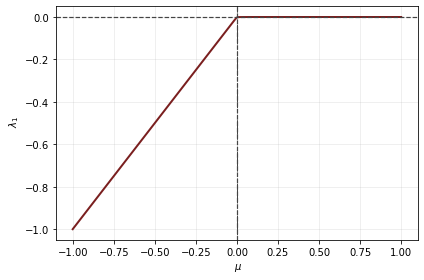

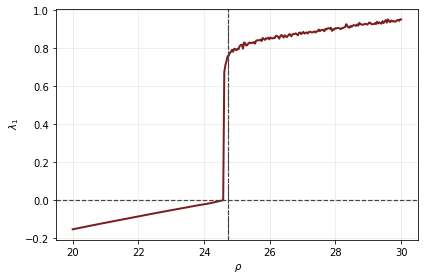

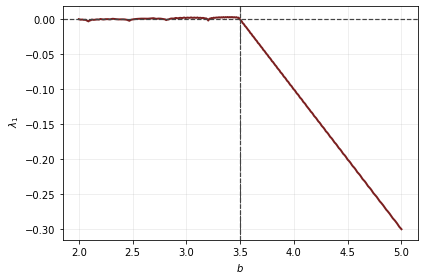

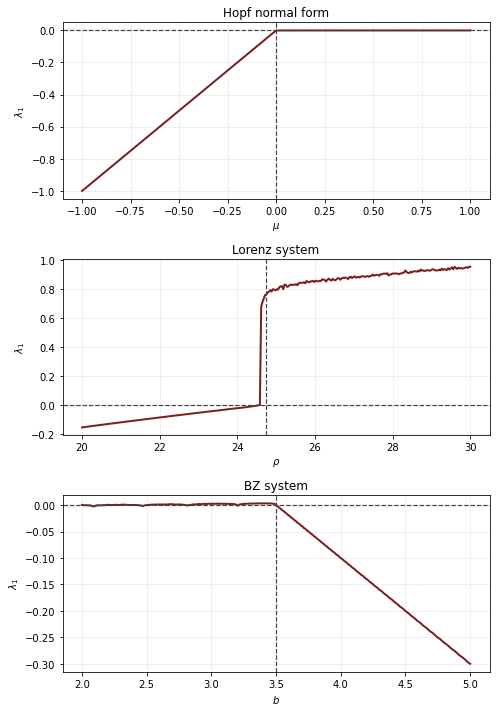

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
df_hopf = pd.read_excel("lyapunov_hopf.xlsx")
df_lorenz = pd.read_excel("lyapunov_lorenz.xlsx")
df_bz = pd.read_excel("lyapunov_bz.xlsx")

df_hopf = df_hopf.rename(columns={"mu": "parameter", "lambda1": "lyapunov_max"})
df_lorenz = df_lorenz.rename(columns={"rho": "parameter", "lambda1": "lyapunov_max"})
df_bz = df_bz.rename(columns={"b": "parameter", "lambda1": "lyapunov_max"})

# ============================================================
def clean_lyapunov_df(df, parameter_name="parameter", lyap_name="lyapunov_max"):
    if parameter_name not in df.columns:
        raise ValueError(f"Falta la columna '{parameter_name}'")
    if lyap_name not in df.columns:
        raise ValueError(f"Falta la columna '{lyap_name}'")
    
    out = df[[parameter_name, lyap_name]].copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = out.sort_values(parameter_name).reset_index(drop=True)
    return out

df_hopf = clean_lyapunov_df(df_hopf)
df_lorenz = clean_lyapunov_df(df_lorenz)
df_bz = clean_lyapunov_df(df_bz)


# ============================================================
def plot_lyapunov_vs_parameter(df, system_name, x_label, critical_value=None,
                               figsize=(6,4), save_path=None):
    x = df["parameter"].values
    y = df["lyapunov_max"].values

    plt.figure(figsize=figsize)
    plt.plot(x, y, linewidth=2, color="#7A1F1F")
    plt.axhline(0, linewidth=1.2, linestyle="--", color="#444444")
    plt.axvline(critical_value, linewidth=1.2, linestyle="--", color="#444444")
    
    if critical_value is not None:
        plt.axvline(critical_value, linewidth=1, linestyle="--",color="#444444")

    plt.xlabel(x_label)
    plt.ylabel(r" $\lambda_1$")
    #plt.title(f"{system_name}: Largest Lyapunov exponent")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
plot_lyapunov_vs_parameter(
    df_hopf,
    system_name="Hopf normal form",
    x_label=r" $\mu$",
    critical_value=0.0,
    save_path="lyapunov_hopf.pdf"
)

plot_lyapunov_vs_parameter(
    df_lorenz,
    system_name="Lorenz system",
    x_label=r" $\rho$",
    critical_value=24.74,   # ajusta si quieres
    save_path="lyapunov_lorenz.pdf"
)

plot_lyapunov_vs_parameter(
    df_bz,
    system_name="BZ system",
    x_label=r"$b$",
    critical_value=3.5,     # ajusta si quieres
    save_path="lyapunov_bz.pdf"
)

# ============================================================
# 5. FIGURA COMPUESTA OPCIONAL
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(7, 10))

datasets = [
    (df_hopf, "Hopf normal form", r"$\mu$", 0.0),
    (df_lorenz, "Lorenz system", r"$\rho$", 24.74),
    (df_bz, "BZ system", r"$b$", 3.5),
]

for ax, (dfi, title, xlabel, crit) in zip(axes, datasets):
    ax.plot(dfi["parameter"], dfi["lyapunov_max"], linewidth=2, color="#7A1F1F")
    ax.axhline(0, linewidth=1.2, linestyle="--", color="#444444")
    if crit is not None:
        ax.axvline(crit, linewidth=1.2, linestyle="--", color="#444444")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\lambda_1$")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("lyapunov_all_systems.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Correlation table

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# ============================================================
# 1. CARGA DE DATOS DESDE XLSX
# ============================================================

# -------- Max persistence --------
df_mp_hopf = pd.read_excel("max_persistence_hopf.xlsx")
df_mp_lorenz = pd.read_excel("max_persistence_lorenz.xlsx")
df_mp_bz = pd.read_excel("max_persistence_bz.xlsx")

# -------- Lyapunov --------
df_lyap_hopf = pd.read_excel("lyapunov_hopf.xlsx")
df_lyap_lorenz = pd.read_excel("lyapunov_lorenz.xlsx")
df_lyap_bz = pd.read_excel("lyapunov_bz.xlsx")

# Normalizar nombres de columnas
for df in [df_mp_hopf, df_mp_lorenz, df_mp_bz, df_lyap_hopf, df_lyap_lorenz, df_lyap_bz]:
    df.columns = [str(c).strip().lower() for c in df.columns]

# ============================================================
# 2. RENOMBRAR COLUMNAS A FORMATO ESTANDAR
# ============================================================

# -------- Hopf --------
df_mp_hopf = df_mp_hopf.rename(columns={
    "mu": "parameter",
    "max_persistence_h1": "max_persistence"
})
df_lyap_hopf = df_lyap_hopf.rename(columns={
    "mu": "parameter",
    "lambda1": "lyapunov_max"
})

# -------- Lorenz --------
df_mp_lorenz = df_mp_lorenz.rename(columns={
    "rho": "parameter",
    "max_persistence_noise_0_0": "max_persistence"   # sin ruido
})
df_lyap_lorenz = df_lyap_lorenz.rename(columns={
    "rho": "parameter",
    "lambda1": "lyapunov_max"
})

# -------- BZ --------
df_mp_bz = df_mp_bz.rename(columns={
    "b": "parameter",
    "max_persistence_noise_0_0": "max_persistence"   # sin ruido
})
df_lyap_bz = df_lyap_bz.rename(columns={
    "b": "parameter",
    "lambda1": "lyapunov_max"
})

# ============================================================
# 3. REDONDEAR PARAMETROS PARA HACER MERGE ROBUSTO
# ============================================================
# Esto evita problemas por diferencias minimas entre grids
for df in [df_mp_hopf, df_mp_lorenz, df_mp_bz, df_lyap_hopf, df_lyap_lorenz, df_lyap_bz]:
    df["parameter"] = pd.to_numeric(df["parameter"], errors="coerce").round(3)

# ============================================================
# 4. MERGE POR PARAMETRO
# ============================================================
df_hopf_corr = pd.merge(df_mp_hopf, df_lyap_hopf, on="parameter", how="inner")
df_lorenz_corr = pd.merge(df_mp_lorenz, df_lyap_lorenz, on="parameter", how="inner")
df_bz_corr = pd.merge(df_mp_bz, df_lyap_bz, on="parameter", how="inner")

# ============================================================
# 5. LIMPIEZA
# ============================================================
def clean_corr_df(df, parameter_name="parameter",
                  functional_name="max_persistence",
                  lyap_name="lyapunov_max"):
    required = [parameter_name, functional_name, lyap_name]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Falta la columna requerida: '{c}'")

    out = df[required].copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = out.sort_values(parameter_name).reset_index(drop=True)
    return out

df_hopf_corr = clean_corr_df(df_hopf_corr)
df_lorenz_corr = clean_corr_df(df_lorenz_corr)
df_bz_corr = clean_corr_df(df_bz_corr)

# ============================================================
# 6. DEBUG RAPIDO
# ============================================================
print("Hopf:", df_hopf_corr.shape)
print(df_hopf_corr.head(), "\n")

print("Lorenz:", df_lorenz_corr.shape)
print(df_lorenz_corr.head(), "\n")

print("BZ:", df_bz_corr.shape)
print(df_bz_corr.head(), "\n")

# ============================================================
# 7. FUNCION PARA CALCULAR CORRELACIONES
# ============================================================
def compute_correlation_row(system_name, df,
                            functional_col="max_persistence",
                            lyap_col="lyapunov_max"):
    x = df[functional_col].values
    y = df[lyap_col].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    return {
        "System": system_name,
        "Pearson r": pearson_r,
        "Pearson p-value": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p-value": spearman_p,
        "N": len(df)
    }

# ============================================================
# 8. CONSTRUIR TABLA AUTOMATICAMENTE
# ============================================================
rows = []
rows.append(compute_correlation_row("Hopf normal form", df_hopf_corr))
rows.append(compute_correlation_row("Lorenz", df_lorenz_corr))
rows.append(compute_correlation_row("BZ", df_bz_corr))

corr_table = pd.DataFrame(rows)

# Version redondeada para mostrar
corr_table_display = corr_table.copy()
for col in ["Pearson r", "Pearson p-value", "Spearman rho", "Spearman p-value"]:
    corr_table_display[col] = corr_table_display[col].map(lambda v: f"{v:.6g}")

print("\n=== Correlation table: max persistence vs largest Lyapunov exponent ===")
print(corr_table_display.to_string(index=False))

# ============================================================
# 9. EXPORTAR TABLA
# ============================================================
corr_table.to_excel("correlation_max_persistence_vs_lyapunov.xlsx", index=False)
corr_table.to_csv("correlation_max_persistence_vs_lyapunov.csv", index=False)

# ============================================================
# 10. GENERAR TABLA LaTeX
# ============================================================
latex_table = corr_table.copy()
latex_table["Pearson r"] = latex_table["Pearson r"].map(lambda v: f"{v:.4f}")
latex_table["Pearson p-value"] = latex_table["Pearson p-value"].map(lambda v: f"{v:.2e}")
latex_table["Spearman rho"] = latex_table["Spearman rho"].map(lambda v: f"{v:.4f}")
latex_table["Spearman p-value"] = latex_table["Spearman p-value"].map(lambda v: f"{v:.2e}")

latex_code = latex_table.to_latex(index=False, escape=False)

print("\n=== LaTeX table ===")
print(latex_code)

with open("correlation_max_persistence_vs_lyapunov.tex", "w", encoding="utf-8") as f:
    f.write(latex_code)

# ============================================================
# 11. VERSION COMPACTA SOLO CON LOS COEFICIENTES
# ============================================================
compact_table = corr_table[["System", "Pearson r", "Spearman rho"]].copy()
compact_table["Pearson r"] = compact_table["Pearson r"].map(lambda v: f"{v:.4f}")
compact_table["Spearman rho"] = compact_table["Spearman rho"].map(lambda v: f"{v:.4f}")

print("\n=== Compact table ===")
print(compact_table.to_string(index=False))

Hopf: (300, 3)
   parameter  max_persistence  lyapunov_max
0     -1.000     8.227284e-15     -1.000000
1     -0.993     1.014262e-14     -0.993311
2     -0.987     1.213504e-14     -0.986622
3     -0.980     1.495869e-14     -0.979933
4     -0.973     1.843839e-14     -0.973244 

Lorenz: (300, 3)
   parameter  max_persistence  lyapunov_max
0     20.000     6.502722e-07     -0.154655
1     20.033     6.995783e-07     -0.153643
2     20.067     8.097591e-07     -0.152290
3     20.100     8.803390e-07     -0.151156
4     20.134     1.006725e-06     -0.150081 

BZ: (300, 3)
   parameter  max_persistence  lyapunov_max
0       2.00         2.275007      0.000418
1       2.01         2.292833      0.000050
2       2.02         2.288510     -0.000321
3       2.03         2.285165     -0.000037
4       2.04         2.128414     -0.000243 


=== Correlation table: max persistence vs largest Lyapunov exponent ===
          System Pearson r Pearson p-value Spearman rho Spearman p-value   N
Hopf no

/var/folders/m9/hs1cz9517vz964jjlxpfd66h0000gn/T/ipykernel_42705/521540921.py:157: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_code = latex_table.to_latex(index=False, escape=False)
